In [133]:
import numpy as np
import random
import pandas as pd
from sklearn.datasets import make_classification

In [134]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [135]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.902775,1.906025,-0.364461,-2.556996,-0.303519,0
1,-1.274319,1.361892,-1.111054,-2.968765,-2.194070,0
2,-1.672167,1.905334,0.472476,-2.371676,-2.266955,0
3,0.221386,-1.953452,-1.153748,0.547961,2.543015,1
4,-4.072135,0.963543,3.678545,2.240280,-1.070446,1


In [136]:
# function for row sampling
# gives randomly rows 
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [137]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [138]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [139]:
df1 = sample_rows(df,0.2)
df1

,col1,col2,col3,col4,col5,target
8,0.131186,-2.458176,0.515375,1.211627,0.435434,1
38,-2.409262,-0.181025,1.292928,2.068017,0.084470,1
57,-1.467865,0.735653,0.573122,1.898597,-0.421497,0
96,-1.913418,-1.263700,-0.170290,0.192146,1.570426,1
58,-0.989780,0.862629,-0.714560,-0.685199,-2.436099,0
21,-3.637834,2.389593,1.545750,-0.372118,-0.514445,0
31,-0.755281,0.586119,0.658030,0.230635,-1.632856,0
61,-1.300474,1.124128,0.432899,0.360793,-0.375078,0
84,0.077984,1.066872,1.184562,-0.937771,-2.042610,0
25,-1.867271,1.379642,0.631261,0.732226,0.876786,0


In [140]:
df2 = sample_rows(df,0.2)
df2

,col1,col2,col3,col4,col5,target
71,-0.635827,0.460313,0.871200,1.948840,-0.619009,0
38,-2.409262,-0.181025,1.292928,2.068017,0.084470,1
88,-1.201263,-1.193131,-0.248203,0.892527,2.026059,1
44,-1.691499,1.643411,1.226331,1.639949,-0.669895,0
41,-2.101000,-1.392324,-1.911163,0.977876,2.288318,1
49,-1.609447,1.632308,2.458184,-0.194885,-0.759115,0
95,-0.165764,-0.623431,0.974286,-0.152671,2.373360,1
49,-1.609447,1.632308,2.458184,-0.194885,-0.759115,0
77,-1.848083,-1.651080,-0.992277,1.528317,1.826207,1
64,-0.426893,0.672065,-1.052198,-1.573279,-2.031632,0


In [141]:
df3 = sample_rows(df,0.2)
df3

,col1,col2,col3,col4,col5,target
79,0.220579,0.896051,2.789879,1.019241,1.438940,1
88,-1.201263,-1.193131,-0.248203,0.892527,2.026059,1
65,-2.223193,-2.817318,-3.641936,0.817274,2.510093,1
0,-1.902775,1.906025,-0.364461,-2.556996,-0.303519,0
85,-2.271327,1.289210,2.157535,2.237887,-0.749687,0
74,0.773837,-2.835767,0.176090,0.364874,0.985685,1
47,-1.957678,-0.131375,1.149715,2.800512,0.984574,1
36,-2.702115,2.280900,2.578476,1.239364,-1.276476,0
99,-1.094763,-0.490051,1.635337,1.785659,0.302091,1
94,0.855695,-1.604952,0.437500,-0.225382,2.571299,1


In [142]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')


In [143]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [144]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [145]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[1] <= 0.028\ngini = 0.375\nsamples = 20\nvalue = [15, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.625, 0.5, '  False')]

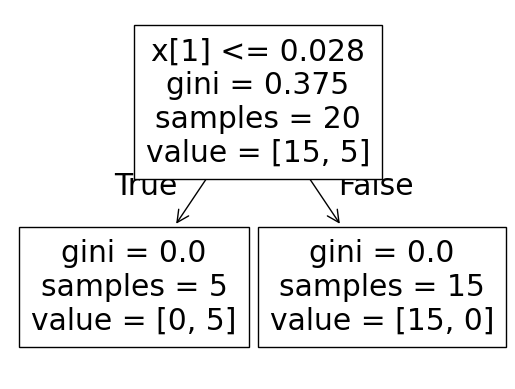

In [146]:
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[4] <= -0.246\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= -2.62\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]')]

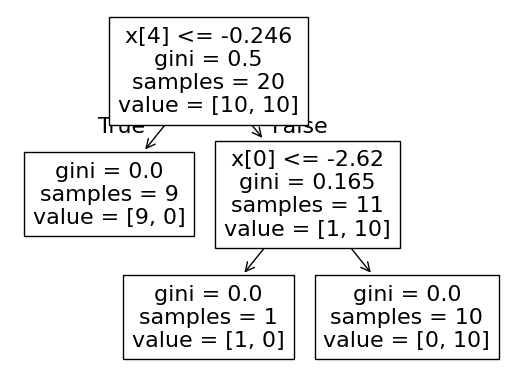

In [147]:
plot_tree(clf2)

[Text(0.6, 0.875, 'x[1] <= 1.126\ngini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(0.4, 0.625, 'x[3] <= 2.251\ngini = 0.337\nsamples = 14\nvalue = [3, 11]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.6, 0.375, 'x[2] <= 0.989\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.7, 0.75, '  False')]

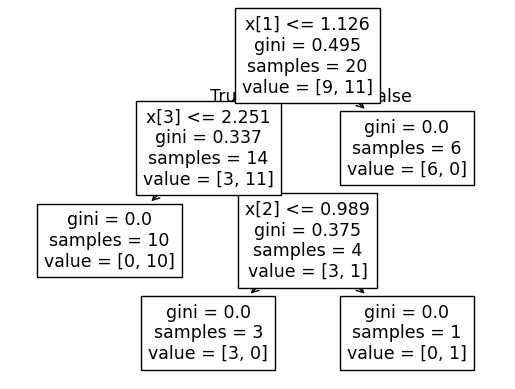

In [148]:
plot_tree(clf3)

In [149]:
clf1.predict(np.array([-1.042498,	-0.064323,-1.807618,-1.557932,-0.039809]).reshape(1,5))

F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [150]:
clf2.predict(np.array([-1.042498,	-0.064323,-1.807618,-1.557932,-0.039809]).reshape(1,5))

F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [151]:
clf3.predict(np.array([-1.042498,	-0.064323,-1.807618,-1.557932,-0.039809]).reshape(1,5))

F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [152]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
19,-3.115714,3.834078,3.722570,-2.582563,-1.328838,0
12,-0.706052,-0.407705,0.762019,3.767334,-1.088711,0
58,-0.989780,0.862629,-0.714560,-0.685199,-2.436099,0
85,-2.271327,1.289210,2.157535,2.237887,-0.749687,0
29,2.900455,-2.099084,3.041592,0.202127,0.421991,1
76,-0.997657,-0.359340,2.347238,1.924117,0.273012,1
18,-0.056070,-1.783839,1.195185,-1.213342,1.625255,1
13,0.881063,-2.396052,0.441322,0.525121,0.865757,1
76,-0.997657,-0.359340,2.347238,1.924117,0.273012,1
91,-0.436497,0.544109,0.829074,2.807267,0.930762,0


In [153]:
df1=sample_features(df,0.8)
df2=sample_features(df,0.8)
df3=sample_features(df,0.8)

C:\Users\KRYPTON-BOOK\AppData\Local\Temp\ipykernel_19964\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\KRYPTON-BOOK\AppData\Local\Temp\ipykernel_19964\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\KRYPTON-BOOK\AppData\Local\Temp\ipykernel_19964\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

In [154]:
df1

,col4,col2,col3,col5,target
0,-2.556996,1.906025,-0.364461,-0.303519,0
1,-2.968765,1.361892,-1.111054,-2.194070,0
2,-2.371676,1.905334,0.472476,-2.266955,0
3,0.547961,-1.953452,-1.153748,2.543015,1
4,2.240280,0.963543,3.678545,-1.070446,1
...,...,...,...,...,...
95,-0.152671,-0.623431,0.974286,2.373360,1
96,0.192146,-1.263700,-0.170290,1.570426,1
97,0.183685,1.107586,0.927039,-1.395154,0
98,2.478588,0.779368,0.620800,-0.343104,0


In [155]:
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [156]:
from sklearn.tree import plot_tree

[Text(0.5, 0.9166666666666666, 'x[3] <= -0.272\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.3333333333333333, 0.75, 'x[2] <= 3.602\ngini = 0.159\nsamples = 46\nvalue = [42, 4]'),
 Text(0.41666666666666663, 0.8333333333333333, 'True  '),
 Text(0.2, 0.5833333333333334, 'x[1] <= 0.203\ngini = 0.046\nsamples = 42\nvalue = [41, 1]'),
 Text(0.13333333333333333, 0.4166666666666667, 'x[1] <= -0.099\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.06666666666666667, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.2, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.26666666666666666, 0.4166666666666667, 'gini = 0.0\nsamples = 36\nvalue = [36, 0]'),
 Text(0.4666666666666667, 0.5833333333333334, 'x[3] <= -1.266\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.4, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5333333333333333, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6666666666666666, 0.75, 'x[1] <= 0.06

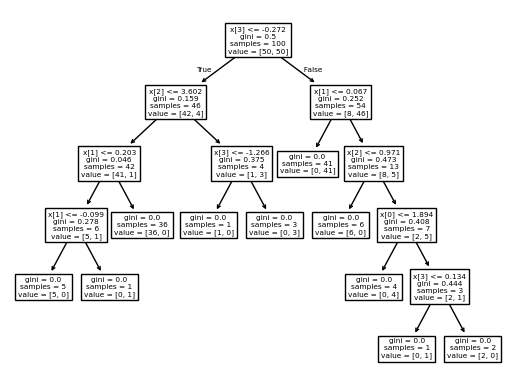

In [157]:
plot_tree(clf1)

[Text(0.43333333333333335, 0.9, 'x[0] <= 0.067\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.2, 0.7, 'x[2] <= 3.01\ngini = 0.194\nsamples = 46\nvalue = [5, 41]'),
 Text(0.31666666666666665, 0.8, 'True  '),
 Text(0.13333333333333333, 0.5, 'x[0] <= -0.637\ngini = 0.089\nsamples = 43\nvalue = [2, 41]'),
 Text(0.06666666666666667, 0.3, 'gini = 0.0\nsamples = 32\nvalue = [0, 32]'),
 Text(0.2, 0.3, 'x[3] <= -0.017\ngini = 0.298\nsamples = 11\nvalue = [2, 9]'),
 Text(0.13333333333333333, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.26666666666666666, 0.1, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.26666666666666666, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6666666666666666, 0.7, 'x[3] <= 2.752\ngini = 0.278\nsamples = 54\nvalue = [45, 9]'),
 Text(0.55, 0.8, '  False'),
 Text(0.5333333333333333, 0.5, 'x[1] <= -2.733\ngini = 0.089\nsamples = 43\nvalue = [41, 2]'),
 Text(0.4666666666666667, 0.3, 'x[0] <= 1.352\ngini = 0.444\nsamples = 3\nvalue = [1,

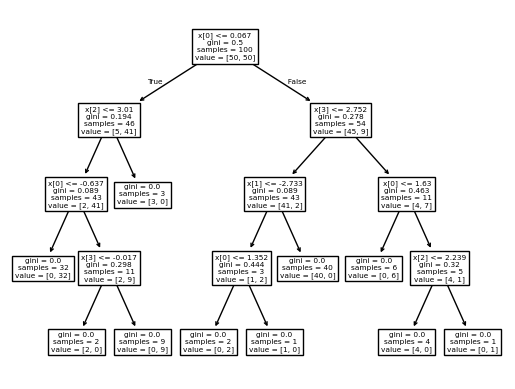

In [158]:
plot_tree(clf2)

[Text(0.5357142857142857, 0.9166666666666666, 'x[2] <= -0.272\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.35714285714285715, 0.75, 'x[3] <= 3.602\ngini = 0.159\nsamples = 46\nvalue = [42, 4]'),
 Text(0.4464285714285714, 0.8333333333333333, 'True  '),
 Text(0.21428571428571427, 0.5833333333333334, 'x[1] <= -2.733\ngini = 0.046\nsamples = 42\nvalue = [41, 1]'),
 Text(0.14285714285714285, 0.4166666666666667, 'x[0] <= 1.014\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.07142857142857142, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.21428571428571427, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2857142857142857, 0.4166666666666667, 'gini = 0.0\nsamples = 39\nvalue = [39, 0]'),
 Text(0.5, 0.5833333333333334, 'x[2] <= -1.266\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.42857142857142855, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5714285714285714, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]')

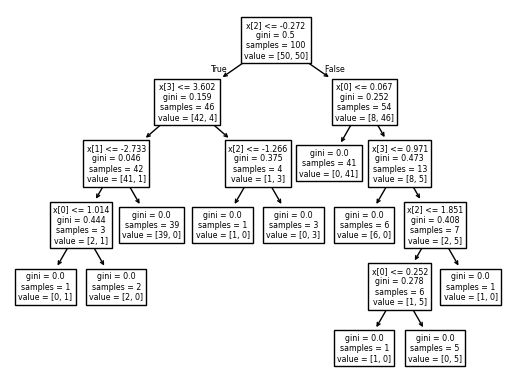

In [159]:
plot_tree(clf3)

In [160]:
clf1.predict(np.array([-1.152498,-0.494323,1.347618,0.471468]).reshape(1,4))

F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [161]:
clf2.predict(np.array([-1.152498,-0.494323,1.347618,0.471468]).reshape(1,4))

F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [162]:
clf3.predict(np.array([-1.152498,-0.494323,1.347618,0.471468]).reshape(1,4))

F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [163]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
25,-1.867271,1.379642,0.631261,0.732226,0.876786,0
34,-1.259901,1.586173,-0.057522,-0.834897,-0.713485,0
21,-3.637834,2.389593,1.545750,-0.372118,-0.514445,0
45,-2.628272,1.433005,3.719306,4.798357,-1.202345,1
63,0.072201,-1.715933,1.314009,0.798915,0.812482,1
52,-0.923221,-1.566654,-1.247805,2.774974,1.367080,1
39,-0.333958,0.236797,-2.070936,-0.969879,-1.361327,0
27,0.903864,-1.736590,0.685931,0.610114,1.426177,1
40,-2.644816,2.123469,3.302514,1.985797,2.263968,0
5,-3.521598,-1.314185,-0.330730,2.294223,0.352307,1


In [164]:
df__1=

SyntaxError: invalid syntax (1704353862.py, line 1)